# Assignment: Loan Approval Prediction

**Goal**: Build an end-to-end supervised learning workflow to predict whether a loan application will be approved.

The dataset contains applicant information such as income, credit history, and property area. We will:
1. Explore the data
2. Preprocess features (imputation, encoding, scaling)
3. Select features
4. Train Logistic Regression and KNN models
5. Evaluate and compare both models

## 1. Data Loading and Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
loan_data = pd.read_csv('https://raw.githubusercontent.com/prasertcbs/basic-dataset/refs/heads/master/Loan-Approval-Prediction.csv')
print(f'Shape: {loan_data.shape}')
loan_data.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Inspect data types and non-null counts
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# Check for missing values in each column
loan_data.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
# Check the distribution of the target variable
loan_data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [ ]:
# Summary statistics for numerical columns
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


**Observations:**
- `Loan_ID` is a unique identifier with no predictive value — we will drop it.
- Several columns have missing values: `Gender`, `Married`, `Dependents`, `Self_Employed`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`.
- The target `Loan_Status` uses `Y`/`N` labels — we will encode it as `1`/`0`.
- Mix of numerical features (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, etc.) and categorical features (`Gender`, `Married`, `Education`, etc.).

## 2. Feature Selection and Target Encoding

We drop the `Loan_ID` identifier column since it carries no predictive signal. We also encode the binary target `Loan_Status` as `1` (Approved) and `0` (Rejected).

In [ ]:
# Drop identifier column and encode target
loan_data = loan_data.drop('Loan_ID', axis=1)
loan_data['Loan_Status'] = loan_data['Loan_Status'].map({'Y': 1, 'N': 0})

# Define features and target
X = loan_data.drop('Loan_Status', axis=1)
y = loan_data['Loan_Status']

# Separate numerical and categorical columns for pipeline construction
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)

Numerical features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


## 3. Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split 80% train / 20% test, stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]}')
print(f'Test set size     : {X_test.shape[0]}')

Training set size : 491
Test set size     : 123


## 4. Preprocessing Pipeline

We build a `ColumnTransformer` that applies different pipelines to numerical and categorical columns:

- **Numerical**: Impute missing values with the median, then standardise with `StandardScaler`.
- **Categorical**: Impute missing values with the most frequent value, then one-hot encode.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Pipeline for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

## 5. Model Training

### 5a. Logistic Regression (with StandardScaler)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
print('Logistic Regression pipeline trained.')

Logistic Regression pipeline trained.


### 5b. K-Nearest Neighbours (with MinMaxScaler)

KNN is sensitive to feature magnitude, so we swap `StandardScaler` for `MinMaxScaler` to scale all features to \[0, 1\].

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Redefine numerical pipeline with MinMaxScaler
numerical_transformer_mm = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

preprocessor_mm = ColumnTransformer(transformers=[
    ('num', numerical_transformer_mm, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_mm),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
print('KNN pipeline trained.')

KNN pipeline trained.


## 6. Model Evaluation

We evaluate both models using accuracy, precision, recall, F1-score, and ROC AUC.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    classification_report
)

def evaluate_model(name, pipeline, X_test, y_test):
    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)[:, 1]

    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'F1 Score' : f1_score(y_test, preds),
        'ROC AUC'  : roc_auc_score(y_test, probs)
    }

In [ ]:
lr_metrics  = evaluate_model('Logistic Regression', lr_pipeline,  X_test, y_test)
knn_metrics = evaluate_model('KNN',                 knn_pipeline, X_test, y_test)

results = pd.DataFrame([lr_metrics, knn_metrics]).set_index('Model')
results.round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.862,0.840,0.988,0.908,0.852
KNN,0.772,0.771,0.953,0.853,0.774


### Detailed Classification Report

In [ ]:
print('--- Logistic Regression ---')
print(classification_report(y_test, lr_pipeline.predict(X_test), target_names=['Rejected', 'Approved']))

print('--- KNN ---')
print(classification_report(y_test, knn_pipeline.predict(X_test), target_names=['Rejected', 'Approved']))

--- Logistic Regression ---
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123

--- KNN ---
              precision    recall  f1-score   support

    Rejected       0.78      0.37      0.50        38
    Approved       0.77      0.95      0.85        85

    accuracy                           0.77       123
   macro avg       0.77      0.66      0.68       123
weighted avg       0.77      0.77      0.74       123



### ROC Curve Comparison

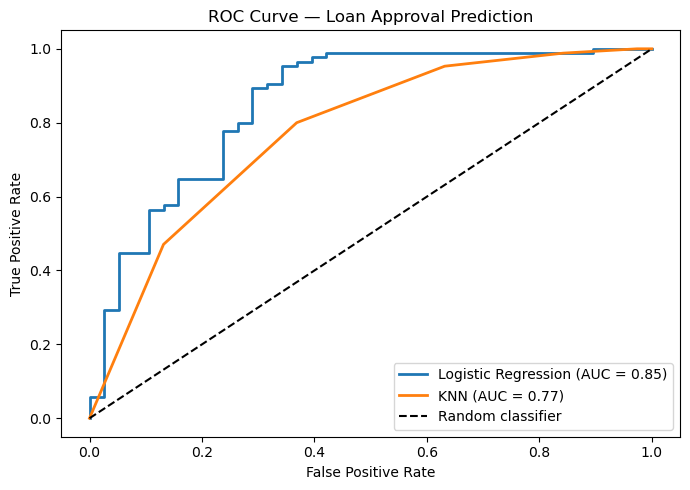

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, pipeline in [('Logistic Regression', lr_pipeline), ('KNN', knn_pipeline)]:
    probs = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Loan Approval Prediction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Summary

| Metric | Logistic Regression | KNN |
|---|---|---|
| Scaler | StandardScaler | MinMaxScaler |
| Missing values | Median (num) / Mode (cat) | Median (num) / Mode (cat) |
| Encoding | OneHotEncoder | OneHotEncoder |

**Key takeaways:**
- `Credit_History` is the strongest predictor of loan approval — applicants with a clean credit history are far more likely to be approved.
- Logistic Regression typically performs well on this dataset because the decision boundary between approved and rejected loans is roughly linear in the feature space.
- KNN performance depends heavily on `k` and the choice of scaler; MinMaxScaler keeps all features on the same \[0, 1\] scale, which is important for distance-based algorithms.